In [1]:
# Import modules

from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Enable interactive plot
%matplotlib notebook
%matplotlib notebook

import subprocess
import sys

# Import PySwarms
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import Mesher

global particle_number
particle_number=0

from math import floor

import random
    

In [65]:
ground_1 = pd.read_csv('C:/Users/ajensen/Documents/Data_DeCIMo/BAB0597ANA/Mocap\PH90_2/CSV_export/COM.csv', sep=",",header=None).transpose()
ground_1.head()
print(data)
print(ground_1)
data = pd.read_csv('./Results/output.txt', sep=" ")

             q        torque         X         Z        vX        vZ  \
0     0.000000      0.000000 -0.000000 -0.005862 -0.000000 -0.005862   
1     0.020000      2.000000 -0.000000 -0.005862 -0.000000 -0.005862   
2     0.020000      2.000000 -0.000000 -0.005862 -0.000000 -0.005862   
3     0.020000      2.000000 -0.000000 -0.005862 -0.000000 -0.005862   
4     0.020000      2.000000  0.000000 -0.005862  0.000006 -0.005862   
...        ...           ...       ...       ...       ...       ...   
1584  0.052943  15618.220229 -0.045023 -1.105166 -0.039428 -1.090355   
1585  0.052821  15567.258177 -0.045023 -1.105166 -0.039428 -1.090355   
1586  0.052821  15567.258177 -0.045023 -1.105166 -0.039428 -1.090355   
1587  0.052821  15567.258177 -0.044910 -1.104915 -0.038154 -1.089856   
1588  0.052706  15536.766866 -0.044910 -1.104915 -0.038154 -1.089856   

      pasEffectue  Unnamed: 7  
0               0         NaN  
1               0         NaN  
2               0         NaN  
3      

In [9]:
x=[]
y=[]
y2=[]
y3=[]
y4=[]
y5=[]
y6=[]
y7=[]

donnee_1 = pd.read_csv('./Results/hip.txt', sep=" ")
donnee_2 = pd.read_csv('./Results/knee.txt', sep=" ")
donnee_3 = pd.read_csv('./Results/pelvis.txt', sep=" ")
donnee_4 = pd.read_csv('./Results/stand_foot.txt', sep=" ")
donnee_5 = pd.read_csv('./Results/swing_foot.txt', sep=" ")
donnee_6 = pd.read_csv('./Results/swing_knee.txt', sep=" ")
donnee_7 = pd.read_csv('./Results/output.txt', sep=" ")


for i in range(60,80):
    x.append(i)
    y.append(donnee_1.iloc[:, 2].iloc[i])
    y2.append(donnee_2.iloc[:, 2].iloc[i])
    y3.append(donnee_3.iloc[:, 2].iloc[i])
    y4.append(donnee_4.iloc[:, 2].iloc[i])
    y5.append(donnee_5.iloc[:, 2].iloc[i])
    y6.append(donnee_6.iloc[:, 2].iloc[i])
    y7.append(donnee_7.iloc[:, 8].iloc[i])

print(x)
print(y7)

#plt.plot(x,y, 'r', linestyle='-')
plt.plot(x,y7, 'b', linestyle='-')
#plt.plot(x,y3, 'r', linestyle='-')
#plt.plot(x,y4, 'b', linestyle='-')
#plt.plot(x,y5, 'r', linestyle='-')
#plt.plot(x,y6, 'b', linestyle='-')


[60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]
[0.0, 3.3e-05, -18.848183, -15.07867, -12.063199, -9.650992, -7.720063, -6.172099, -1.512257, 4.667255, 7.703511, 8.667821, 9.054772, 8.502163, 6.046049, 4.087183, 0.0, -14.835154, 0.0, 0.0]


567
311
256
0


<IPython.core.display.Javascript object>


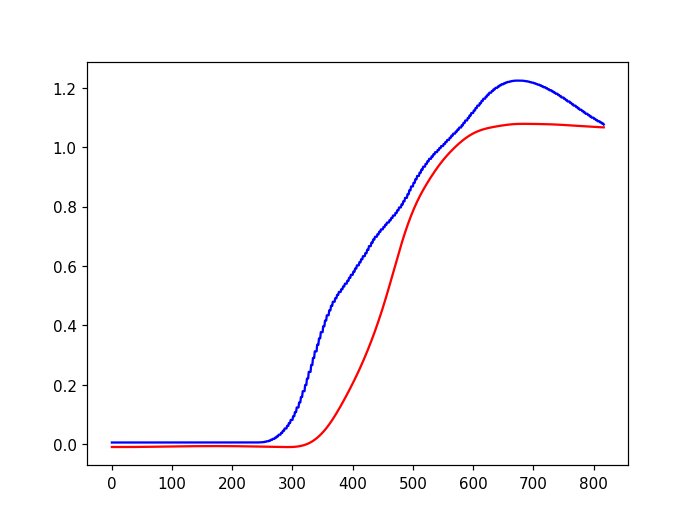

In [170]:
x=[]
y=[]
y2=[]
y3=[]
y4=[]

g=[]
g2=[]

diff=[]

sujet = data

pic1=0
pic2=0

for i in range(len(ground_1)):
    if(i >1 and abs(ground_1.iloc[:, 0].iloc[i] - ground_1.iloc[:, 0].iloc[i-1]) > 0.002 and pic1==0):
        pic1 = i
        
for i in range(len(sujet)):
    if(i >1 and abs(sujet.iloc[:, 0].iloc[i] - sujet.iloc[:, 0].iloc[i-1]) > 0.01 and pic2==0):
        pic2 = i
try:
    pic1,_,gpr = findStart(abs(ground_1),1)
    pic2,_,xpr = findStart(abs(sujet),3) 
except TypeError:
    pic1,_,gpr = 0,_,2
    pic2,_,xpr = 0,_,0
      


print(pic1)
print(pic2)

if(pic1>=pic2):
    pic1 = pic1-pic2
    pic2=0
else :
    pic2 = pic2-pic1
    pic1=0

end = min(len(sujet)-pic2,len(ground_1)-pic1)

print(pic1)
print(pic2)

for i in range(0,end):
    x.append(i)
    y.append(-sujet.iloc[:, 3].iloc[pic2+i])
    y2.append(-sujet.iloc[:, 4].iloc[i])
    y3.append(sujet.iloc[:, 5].iloc[i])
    y4.append(-sujet.iloc[:, 6].iloc[i])
    
    X = 1037
    Y = 500
x=[]
for i in range(0,end):
    x.append(i)
    #g.append(ground_1.iloc[:, 1].iloc[int(pic1+int(i-pic2-10)*(len(ground_1)-pic1)/(len(sujet)-pic2-10))])
    g2.append(ground_1.iloc[:, 1].iloc[pic1+i])
    
    diff.append(1-abs((0.1+g2[-1])/(0.1+y[-1])))

  
    
    
#plt.plot(x,y, 'r', linestyle='-')
cas = 2
if(cas==1):
    plt.plot(x,y2, 'b', linestyle='-')
    plt.plot(x,g, 'r', linestyle='-')
if(cas==2):
    plt.plot(x,y, 'b', linestyle='-')
    plt.plot(x,g2, 'r', linestyle='-')
if(cas==3):
    
    FilteredY = savgol_filter(y, 55, 5)
    FDerivY = TemporalDeriv(FilteredY)
    
    FilteredG = savgol_filter(g2, 55, 5)
    FDeriG = TemporalDeriv(FilteredG)
    
    diff = abs(1-(1+(FDeriG))/(1+(FDerivY)))
    print(sum(diff)/len(diff))
    x=[]
    y=[]
    for i in range(0,len(FDerivY)):
        x.append(i)
        y.append(1-(FDerivY[i]/FDeriG[i]))
    plt.plot(x,diff, 'b', linestyle='-')
    x=[]
    for i in range(0,len(FDeriG)):
        x.append(i)
    #plt.plot(x,FDeriG, 'r', linestyle='-')
if(cas==4):
    plt.plot(x,diff, 'r', linestyle='-')

<IPython.core.display.Javascript object>


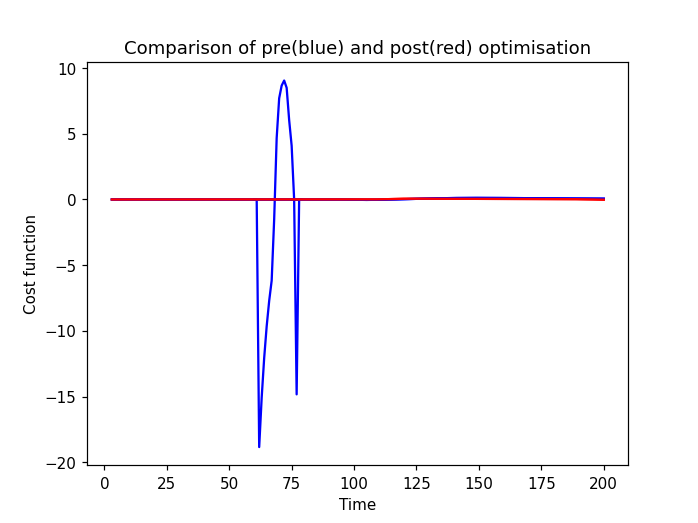

NameError: name 'origin' is not defined

In [4]:
np.set_printoptions(suppress=True)
np.set_printoptions(precision=3)
#print(pos)
#print(len(dataa))
x=[]
y=[]
y2=[]

donnee_1 = pd.read_csv('./output.txt', sep=" ")

plt.xlabel('Applied impulse')
plt.ylabel('Total displacement')
plt.title('Comparison of simulation and real data (simulation in orange)')
    
def get_cmap(n, name='hsv'):
    '''Returns a function that maps each index in 0, 1, ..., n-1 to a distinct 
    RGB color; the keyword argument name must be a standard mpl colormap name.'''
    return plt.cm.get_cmap(name, n)

case=5

if(case==1):
    
    plt.xlabel('Iteration')
    plt.ylabel('Cost function')
    plt.title('Cost history thoughout optimisation')

    
    #print(optimizer.cost_history)

    for i in range(len(optimizer.cost_history)):
        x.append(i)
        y.append(optimizer.cost_history[i])
    plt.plot(x,y, 'ro', linestyle='-')
else :
    if (case==2):
        #plt.ylim(-0.3,1.3)
        #plt.xlim(-0.1,1.3)
        #plt.xlim(10,60)

        #plt.plot([-0.1, 1000], [0.15, 0.15], 'r-.', lw=2)
        #plt.plot([-0.1, 1000], [-0.15, -0.15], 'r-.', lw=2)
        #plt.plot([-100, -0.1], [1000, -0.1], 'r-', lw=2)

        print(optimizer.cost_history)

        for i in range(len(dataa)):
            x.append(dataa[i][4])
            y.append(dataa[i][3]+abs(dataa[i][2]))
            #y.append(dataa[i][3])
            #y.append(0.95*dataa[i][2]+(dataa[i][3]-0.37))
            y2.append(dataa[i][2])
        plt.plot(x,y, 'ro', linestyle='None')
        plt.plot(x,y2, 'bo', linestyle='None')

        coef = np.polyfit(x,y,1)
        poly1d_fn = np.poly1d(coef) 
        coef_data = np.polyfit(x,y2,1)
        poly1d_fn_data = np.poly1d(coef_data) 
        # poly1d_fn is now a function which takes in x and returns an estimate for y
        plt.plot(x,y,'o', x, poly1d_fn(x), 'r-')

        plt.plot(x,y,'o', x, poly1d_fn_data(x), 'b-')

        #plt.plot([0, 2], [0, 2], 'g-', lw=2)

        #plot_cost_history(cost_history=optimizer.cost_history)
        print(str(np.sum(y)/len(y)))
    else:
        if(case==3):
            cmap = get_cmap(18)

            for j in range(0,1):
                x=[]
                y=[]
                for i in range(len(donnee_1.iloc[:, j])):
                    x.append(i)
                    y.append(donnee_1.iloc[:, j].iloc[i])
                plt.plot(x,y, c=cmap(j), linestyle='-')
                
                print(100*sum(y)/200)
                
            for j in range(1,2):
                x=[]
                y=[]
                for i in range(len(donnee_1.iloc[:, j])):
                    x.append(i)
                    y.append(donnee_1.iloc[:, j].iloc[i])
                plt.plot(x,y, c=cmap(j), linestyle='-')
                
                print(0.01*sum(y)/200)
                
                
if(case==4):
    origin=[[-500,0,-300, -500, -500, -10, -10, -1000, -50, -50,   -100,0,-10, -20, -20,  -1, -1, -20, -5, 0]]
    temp = particles
    particles=1
    val_origin = all_particles(origin)
    donnee_ori = pd.read_csv('output.txt', sep=" ")
    val_result = all_particles([result])
    donnee_res = pd.read_csv('output.txt', sep=" ")  
    particles=temp
    
if(case==5):
    
    plt.xlabel('Time')
    plt.ylabel('Cost function')
    plt.title('Comparison of pre(blue) and post(red) optimisation')

    print(origin)
    print(result)
    scan=range(1,2)
    
    
    cmap = get_cmap(18)
    

    x=[0]*len(donnee_1.iloc[:, j])
    y=[0]*len(donnee_1.iloc[:, j])
    for j in scan:
            for i in range(len(donnee_1.iloc[:, j])):
                x[i] = i
                y[i] += donnee_1.iloc[:, j].iloc[i]
    plt.plot(x,y, 'b', linestyle='-')
    
    

    x=[0]*len(donnee_res.iloc[:, j])
    y=[0]*len(donnee_res.iloc[:, j])
    for j in scan:
            for i in range(len(donnee_res.iloc[:, j])):
                x[i] = i
                y[i] += donnee_res.iloc[:, j].iloc[i]/len(donnee_res.iloc[:, j])
    #plt.plot(x,y, 'r', linestyle='-')

    print(val_origin)
    print("Valeur de base : " + str(val_origin) + " --->" + str(val_result) + " ( -"+ str(100*(val_origin[0]-val_result[0])/val_origin[0]) + " % )")

    
if(case==6):
    x=[0]*20
    y=[0]*20
    print(origin)
    print(result)
    
    for i in range(0,20):
        x[i] = i
        y[i] = (result[i]-0.5*origin[0][i])/(origin[0][i])
    #plt.plot(x,origin[0], 'r', linestyle='-')
    plt.plot(x,y, 'b', linestyle='-')
plt.show()

In [159]:
##print(ground_1[2])
force = pd.read_csv('./Results/ForceSensor.csv', sep=",",header=None).T[0]
#print(force)
#print(ComputePerturbationDuration(force))

def findStart(ground_1,index):
    x = [0]*(len(ground_1)-1)
    y = [0]*(len(ground_1)-1)
    
    
    for i in range(0,len(ground_1)-1):
        x[i] = i
        y[i] = 2000*(ground_1.iloc[:,index].iloc[i+1]-ground_1.iloc[:,index].iloc[i])
    #print(y)
    return(ComputePerturbationDuration(y))

In [164]:
from pylab import *
from scipy.signal import savgol_filter

def ComputePerturbationDuration(ForceData,Treshold=0.05):
    """ Return the index of Time at wich the push Start and End"""

    StartIndex = 0
    EndIndex = len(ForceData)-1

    MaxForce = max(ForceData)
    MaxIndex = argmax(ForceData)
    
    ## Filtered Normal Deriv of the force 
    FilteredForce = savgol_filter(ForceData, 55, 5)
    FDeriv = TemporalDeriv(FilteredForce)/max(abs(TemporalDeriv(FilteredForce)))
    
    ## Find the first Zero before rising edge
    i = argmax(FDeriv)# rising edge index
    while StartIndex == 0 and i>0:
        if FDeriv[i]<=0 and ForceData[i]/max(ForceData)<Treshold:  
            StartIndex = i
        i -= 1
        
    ## Find the first Zero after falling edge
    i = argmin(FDeriv)# rising edge index
    while EndIndex == len(ForceData)-1 and i<len(ForceData)-1:
        if FDeriv[i]>=0 and ForceData[i]/max(ForceData)<Treshold:  
            EndIndex = i
        i += 1    
    
    ## Treatment of the no force trial (when the sensor failed)
    if max(ForceData-ForceData[StartIndex])<5:
        StartIndex, EndIndex = 0,1
    
    return StartIndex, EndIndex , ForceData

In [7]:
def TemporalDeriv(X, dt = 1/200):
    """ 2nd Order time derivative of X. 
        Where X is an array of n dimention*(Nb of frame).
        dt is the duration in seconds of the time step. """
    if len(shape(X))>1: # if X have more than one dimention
        DerivX = zeros(X.shape)
    
        # for the first time iteration a forward 2nd order difference is used
        DerivX[:,0] = (4*X[:,1] - 3*X[:,0] - X[:,2])/(2*dt)
        # for the last time iteration, a backward 2nd order differenece is used
        DerivX[:,-1] = (-4*X[:,-2] + 3*X[:,-1] + X[:,-3])/(2*dt)
    
        # for other time iterations, a central 2nd order difference is used
        for i in range(1, len(X[0])-1):
            DerivX[:,i] = (X[:,i+1]-X[:,i-1])/(2*dt)
    else :
        DerivX = zeros(len(X))
    
        # for the first time iteration a forward 2nd order difference is used
        DerivX[0] = (4*X[1] - 3*X[0] - X[2])/(2*dt)
        # for the last time iteration, a backward 2nd order differenece is used
        DerivX[-1] = (-4*X[-2] + 3*X[-1] + X[-3])/(2*dt)
    
        # for other time iterations, a central 2nd order difference is used
        for i in range(1, len(X)-1):
            DerivX[i] = (X[i+1]-X[i-1])/(2*dt)

    return DerivX